<a href="https://colab.research.google.com/github/signife/PhotoQA/blob/main/4rd_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install efficientnet_pytorch


  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet_pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16424 sha256=5a4022dd519b6adc82b97b4d8a85c898bb509e5569a187434a16a7f72b2f7cbf
  Stored in directory: /root/.cache/pip/wheels/03/3f/e9/911b1bc46869644912bda90a56bcf7b960f20b5187feea3baf
Successfully built efficientnet_pytorch


In [ ]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from tqdm import tqdm  # Import tqdm for the progress bar
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from efficientnet_pytorch import EfficientNet #!pip install efficientnet_pytorch
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
torch.cuda.empty_cache()
from torch.utils.data import WeightedRandomSampler # for data augmentation

In [ ]:
# Paths
CSV_FILE_PATH = '/content/drive/MyDrive/PhotoQA/undersampled_images_data.csv'
IMAGE_DIR = '/content/drive/MyDrive/PhotoQA/cropdata'

# DataLoader settings
BATCH_SIZE = 16

# Training settings
NUM_EPOCHS = 10
LEARNING_RATE = 0.001

# Normalization parameters for pretrained models
NORMALIZE_MEAN = [0.485, 0.456, 0.406]
NORMALIZE_STD = [0.229, 0.224, 0.225]

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'


In [ ]:
df = pd.read_csv(CSV_FILE_PATH)

# Define a PyTorch Dataset
class SmokeAlarmDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df
        self.image_dir = image_dir
        self.transform = transform
        self.label_map = {"Approved": 1, "Declined": 0}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        job_no = str(self.df.iloc[idx]["job_no"])
        image_name = self.df.iloc[idx]["image_name"]
        label = self.df.iloc[idx]["image_status"]
        label = self.label_map.get(label, 0)

        image_path = os.path.join(self.image_dir, job_no, image_name)

        if not os.path.exists(image_path):
            print(f"Warning: Image not found at {image_path}. Skipping this file.")
            return None, None

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

# Custom collate function to handle missing files
def collate_fn(batch):
    batch = [item for item in batch if item[0] is not None]
    return torch.utils.data.dataloader.default_collate(batch)

# Define transformations for training data with data augmentation
train_transform = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.RandomHorizontalFlip(p=0.5),       # 50% 확률로 좌우 뒤집기
    transforms.RandomRotation(degrees=15),        # -15도에서 15도 사이로 랜덤 회전
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # 밝기, 대비, 채도 조정
    transforms.ToTensor(),
    transforms.Normalize(mean=NORMALIZE_MEAN, std=NORMALIZE_STD)
])

# Define transformations for validation and test data without augmentation
test_transform = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORMALIZE_MEAN, std=NORMALIZE_STD)
])


# Split data into train, validation, and test sets
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['image_status'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['image_status'])

# Initialize the datasets and dataloaders
train_dataset = SmokeAlarmDataset(train_df, IMAGE_DIR, transform=train_transform)
val_dataset = SmokeAlarmDataset(val_df, IMAGE_DIR, transform=test_transform)
test_dataset = SmokeAlarmDataset(test_df, IMAGE_DIR, transform=test_transform)


# 각 클래스의 샘플 수 계산
class_sample_counts = [len(train_df[train_df['image_status'] == 'Approved']),
                       len(train_df[train_df['image_status'] == 'Declined'])]
class_weights = 1. / torch.tensor(class_sample_counts, dtype=torch.float)

# 문자열 상태 ('Approved' 또는 'Declined')에 따라 가중치를 할당
sample_weights = [class_weights[0] if status == 'Approved' else class_weights[1] for status in train_df['image_status']]

# WeightedRandomSampler 설정
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)


#Define the Inception model
class EfficientNetModel(nn.Module):
    def __init__(self):
        super(EfficientNetModel, self).__init__()
        self.model = EfficientNet.from_pretrained('efficientnet-b4')
        self.model._fc = nn.Sequential(
            nn.Linear(self.model._fc.in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 1)  # Binary output
        )

    def forward(self, x):
        x = self.model(x)
        return x

model = EfficientNetModel().to(DEVICE)

# Define loss and optimizer
# class weight regularation
num_class_approved = len(train_df[train_df['image_status'] == 'Approved'])
num_class_declined = len(train_df[train_df['image_status'] == 'Declined'])
class_ratio = num_class_approved / num_class_declined

class_weights = torch.tensor([class_ratio]).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
# optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4) // prevent overfitting

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b4-6ed6700e.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b4-6ed6700e.pth
100%|██████████| 74.4M/74.4M [00:01<00:00, 60.4MB/s]


Loaded pretrained weights for efficientnet-b4


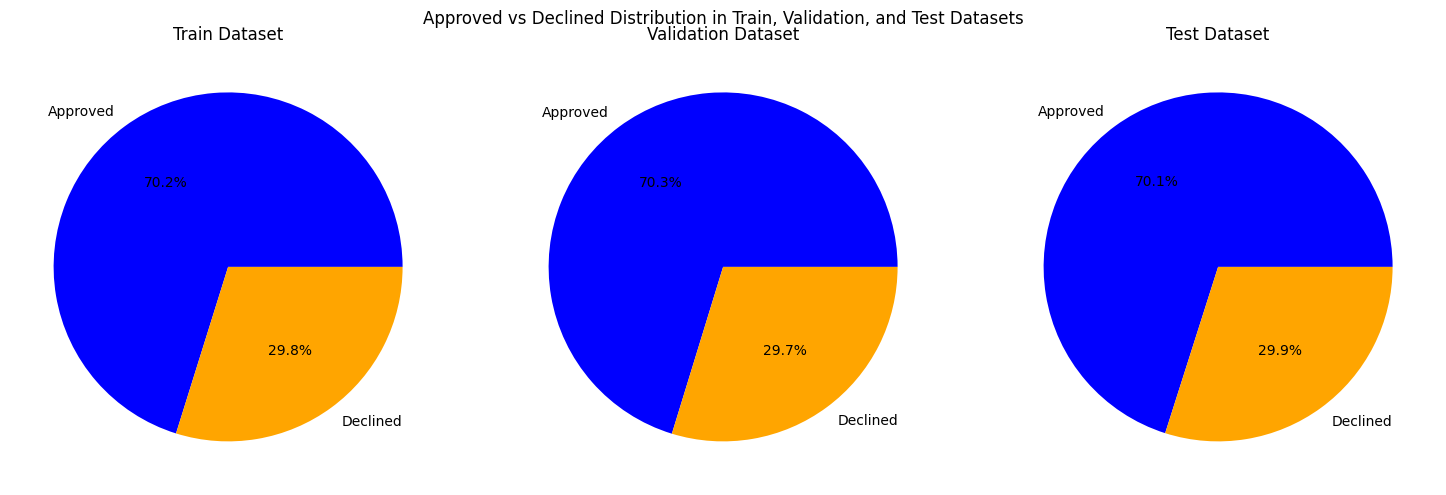

In [ ]:
import matplotlib.pyplot as plt

# Count approved and declined samples in each dataset
train_counts = train_df['image_status'].value_counts()
val_counts = val_df['image_status'].value_counts()
test_counts = test_df['image_status'].value_counts()

# Plot the counts for each dataset as pie charts
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Train set
axs[0].pie(train_counts, labels=['Approved', 'Declined'], autopct='%1.1f%%', colors=['blue', 'orange'])
axs[0].set_title("Train Dataset")

# Validation set
axs[1].pie(val_counts, labels=['Approved', 'Declined'], autopct='%1.1f%%', colors=['blue', 'orange'])
axs[1].set_title("Validation Dataset")

# Test set
axs[2].pie(test_counts, labels=['Approved', 'Declined'], autopct='%1.1f%%', colors=['blue', 'orange'])
axs[2].set_title("Test Dataset")

plt.suptitle("Approved vs Declined Distribution in Train, Validation, and Test Datasets")
plt.tight_layout()
plt.show()



Epoch 1/10:  54%|█████▎    | 67/125 [10:57<07:19,  7.57s/it, loss=0.934]

Epoch 1/10:  87%|████████▋ | 109/125 [15:19<01:35,  5.98s/it, loss=0.611]

Epoch [1/10], Training Loss: 0.6749643332958222
Epoch [1/10], Validation Loss: 0.9149407032463286, F1 Score: 0.8727272727272727


Epoch 2/10:  11%|█         | 14/125 [01:03<10:51,  5.87s/it, loss=0.604]

Epoch 2/10:  49%|████▉     | 61/125 [04:14<03:27,  3.25s/it, loss=0.883]

...

Epoch 9/10:  65%|██████▍   | 81/125 [01:43<00:51,  1.18s/it, loss=0.534]

Epoch 9/10:  78%|███████▊  | 98/125 [02:04<00:32,  1.22s/it, loss=0.469]

Epoch [9/10], Training Loss: 0.3677170836031437
Epoch [9/10], Validation Loss: 1.4344191131768402, F1 Score: 0.9128919860627178


Epoch 10/10:  44%|████▍     | 55/125 [01:07<01:24,  1.20s/it, loss=0.536]

Epoch [10/10], Training Loss: 0.2911321565806866
Epoch [10/10], Validation Loss: 0.6551203045097215, F1 Score: 0.9144736842105263


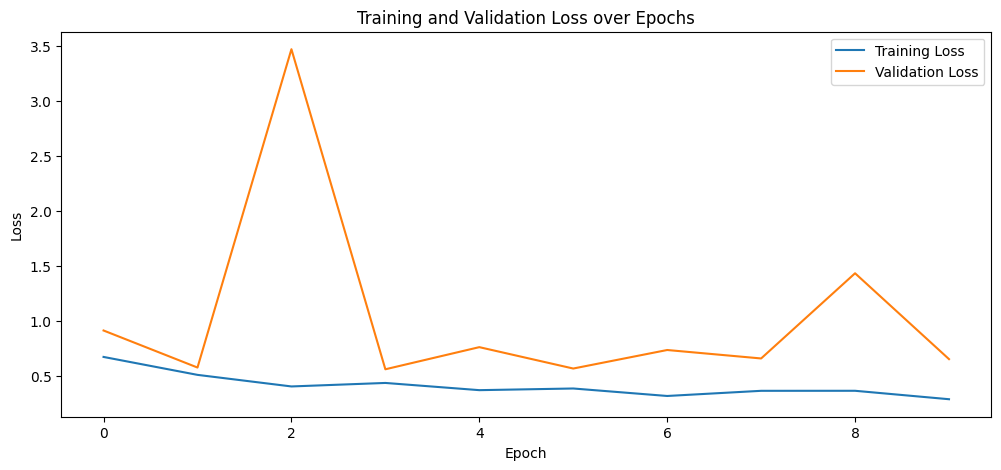

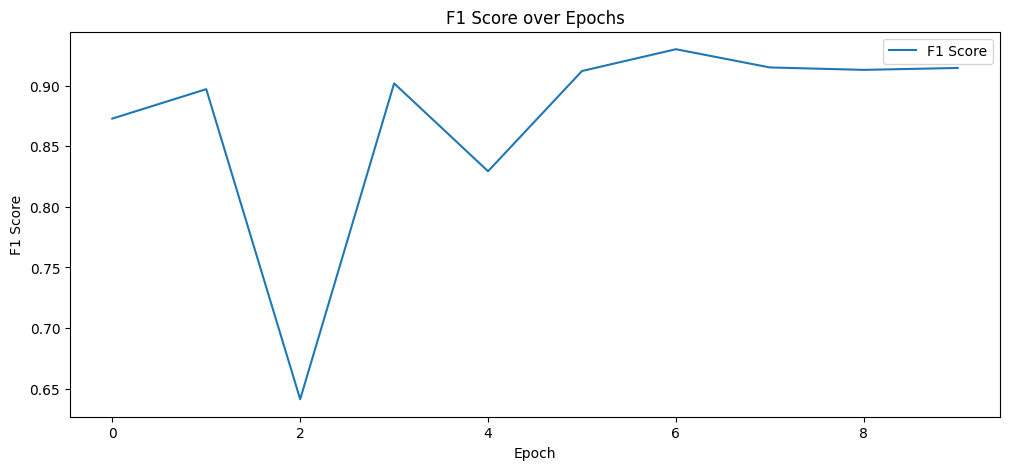

In [ ]:
import matplotlib.pyplot as plt

train_losses = []
val_losses = []
f1_scores = []

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0

    # Training phase
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{NUM_EPOCHS}", leave=False)
    for images, labels in progress_bar:
        labels = labels.unsqueeze(1).float().to(DEVICE)
        images = images.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)  # only main output for efficientnet
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    print(f"Epoch [{epoch + 1}/{NUM_EPOCHS}], Training Loss: {train_loss}")

    # Validation phase
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            labels = labels.unsqueeze(1).float().to(DEVICE)
            images = images.to(DEVICE)

            outputs = model(images)  # Only get main output for validation
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = (torch.sigmoid(outputs) > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = val_loss / len(val_loader)
    val_losses.append(val_loss)

    # Calculate F1 Score
    f1 = f1_score(all_labels, all_preds, average ='binary')
    f1_scores.append(f1)
    print(f"Epoch [{epoch + 1}/{NUM_EPOCHS}], Validation Loss: {val_loss}, F1 Score: {f1}")

# Plot Training and Validation Loss
plt.figure(figsize=(12, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.show()

# Plot F1 Score
plt.figure(figsize=(12, 5))
plt.plot(f1_scores, label='F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.title('F1 Score over Epochs')
plt.legend()
plt.show()

In [ ]:
|